In [ ]:
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Union
import onnx
import onnxruntime as ort
from torch.utils.data import DataLoader, TensorDataset
import os
from google.colab import files

# Same RecurrentEncoder definition as before...
class RecurrentEncoder(torch.nn.Module):
    def __init__(self, input_shape_1, input_shape_2, input_shape_3,
        dense_units_1_1=32, dense_units_1_2=32,
        lstm_units_1_1=32, lstm_units_1_2=32,
        dense_units_2_1=32, dense_units_2_2=32,
        lstm_units_2_1=32, lstm_units_2_2=32,
        dense_units_3_1=128, dense_units_3_2=128, dense_units_3_3=16,
        merge_dense_units_1=64, merge_dense_units_2=32,
        incl_clusters=True, rnn_block=nn.LSTM, wirings=False, lnn_block=False):
        super(RecurrentEncoder, self).__init__()
        self.incl_clusters = incl_clusters

        self.shared_dense_1_1 = torch.nn.Linear(input_shape_1[1], dense_units_1_1)
        self.shared_dense_1_2 = torch.nn.Linear(dense_units_1_1, dense_units_1_2)

        self.rnn_1_1 = rnn_block(input_size=dense_units_1_2, hidden_size=lstm_units_1_1, num_layers=1, batch_first=True)
        self.rnn_1_2 = rnn_block(input_size=lstm_units_1_1, hidden_size=lstm_units_1_2, num_layers=1, batch_first=True)

        if incl_clusters:
            self.shared_dense_2_1 = torch.nn.Linear(input_shape_2[1], dense_units_2_1)
            self.shared_dense_2_2 = torch.nn.Linear(dense_units_2_1, dense_units_2_2)
            self.rnn_2_1 = rnn_block(input_size=dense_units_2_2, hidden_size=lstm_units_2_1, num_layers=1, batch_first=True)
            self.rnn_2_2 = rnn_block(input_size=lstm_units_2_1, hidden_size=lstm_units_2_2, num_layers=1, batch_first=True)

        self.dense_3_1 = nn.Linear(input_shape_3, dense_units_3_1)
        self.dense_3_2 = nn.Linear(dense_units_3_1, dense_units_3_2)
        self.dense_3_3 = nn.Linear(dense_units_3_2, dense_units_3_3)

        total_input_size = lstm_units_1_2 + dense_units_3_3
        total_input_size += lstm_units_2_2 if incl_clusters else 0

        self.merge_branches_1 = torch.nn.Linear(total_input_size, merge_dense_units_1)
        self.merge_branches_2 = torch.nn.Linear(merge_dense_units_1, merge_dense_units_2)
        self.merge_branches_3 = torch.nn.Linear(merge_dense_units_2, 1)

    def forward(self, x1, x3, x2=None):
        out_branch_1 = self.apply_branch_1(x1)
        if self.incl_clusters and x2 is not None:
            out_branch_2 = self.apply_branch_2(x2)
        out_branch_3 = self.apply_branch_3(x3)

        all_features = [out_branch_1]
        if self.incl_clusters and x2 is not None:
            all_features.append(out_branch_2)
        all_features.append(out_branch_3)

        merged_hidden_states = torch.cat(all_features, dim=1)

        output = nn.functional.relu(self.merge_branches_1(merged_hidden_states))
        output = nn.functional.relu(self.merge_branches_2(output))
        output = torch.sigmoid(self.merge_branches_3(output))

        return output.squeeze(-1)

    def apply_branch_1(self, x1):
        hidden_state = nn.functional.relu(self.shared_dense_1_1(x1))
        hidden_state = nn.functional.relu(self.shared_dense_1_2(hidden_state))
        hidden_state, _ = self.rnn_1_1(hidden_state)
        hidden_state_relu = nn.functional.relu(hidden_state)
        hidden_state, _ = self.rnn_1_2(hidden_state_relu)
        return nn.functional.relu(hidden_state[:, -1, :])

    def apply_branch_2(self, x2):
        hidden_state = nn.functional.relu(self.shared_dense_2_1(x2))
        hidden_state = nn.functional.relu(self.shared_dense_2_2(hidden_state))
        hidden_state, _ = self.rnn_2_1(hidden_state)
        hidden_state_relu = nn.functional.relu(hidden_state)
        hidden_state, _ = self.rnn_2_2(hidden_state_relu)
        hidden_state_relu = nn.functional.relu(hidden_state)
        return nn.functional.relu(hidden_state_relu[:, -1, :])

    def apply_branch_3(self, x3):
        hidden_state = nn.functional.relu(self.dense_3_1(x3))
        hidden_state = nn.functional.relu(self.dense_3_2(hidden_state))
        hidden_state = nn.functional.relu(self.dense_3_3(hidden_state))
        return hidden_state

class DiagnosticBranchPatcher:
    """Enhanced version with detailed diagnostics"""

    def __init__(self, model: nn.Module):
        self.model = model
        self._hook_handles = []
        self.branch_endpoints = ["rnn_1_2", "rnn_2_2", "dense_3_3"]
        self.debug_info = {}

    def _create_caching_hook(self, name: str, cache: Dict):
        def hook(module, input, output):
            print(f"  Hook triggered for {name}: {type(module)}")
            if isinstance(output, tuple):
                # For RNN layers
                print(f"    RNN output shape: {output[0].shape}")
                cache[f"{name}_output"] = output[0][:, -1, :].detach().clone()  # Last timestep
                print(f"    Cached {name}_output: {cache[f'{name}_output'].shape}")
            else:
                # For dense layers
                print(f"    Dense output shape: {output.shape}")
                cache[f"{name}_output"] = output.detach().clone()
                print(f"    Cached {name}_output: {cache[f'{name}_output'].shape}")
        return hook

    def _create_patching_hook(self, name: str, patch_activation: torch.Tensor, debug_key: str):
        def hook(module, input, output):
            print(f"  PATCHING {name}: Replacing with shape {patch_activation.shape}")
            self.debug_info[debug_key] = {
                'original_shape': output[0].shape if isinstance(output, tuple) else output.shape,
                'patch_shape': patch_activation.shape,
                'original_mean': (output[0][:, -1, :] if isinstance(output, tuple) else output).mean().item(),
                'patch_mean': patch_activation.mean().item()
            }

            if isinstance(output, tuple):
                # For RNN layers - we need to patch the sequence output
                # Create new sequence with our patch as the last timestep
                new_sequence = output[0].clone()
                new_sequence[:, -1, :] = patch_activation
                return (new_sequence,) + output[1:]
            else:
                # For dense layers
                return patch_activation
        return hook

    def cache_activations(self, inputs: Tuple, cache: Dict, debug_prefix: str):
        """Cache activations with detailed logging"""
        print(f"\n--- Caching activations ({debug_prefix}) ---")
        self.clear_hooks()

        # Register caching hooks
        for name, module in self.model.named_modules():
            if name in self.branch_endpoints:
                print(f"Registering hook for {name}: {type(module)}")
                hook = self._create_caching_hook(name, cache)
                handle = module.register_forward_hook(hook)
                self._hook_handles.append(handle)

        print("Running forward pass...")
        with torch.no_grad():
            output = self.model(*inputs)

        self.clear_hooks()
        print(f"Final output: {output.item():.6f}")

        print("Cached activations:")
        for key, value in cache.items():
            print(f"  {key}: shape={value.shape}, mean={value.mean().item():.6f}")

        return output

    def patch_activation(self, inputs: Tuple, layer_name: str, patch_activation: torch.Tensor, debug_key: str):
        """Patch activation with detailed logging"""
        print(f"\n--- Patching {layer_name} ---")

        # Find the module to patch
        module_to_patch = None
        for name, module in self.model.named_modules():
            if name == layer_name:
                module_to_patch = module
                break

        if module_to_patch is None:
            raise ValueError(f"Layer {layer_name} not found in model")

        print(f"Found module: {type(module_to_patch)}")

        # Register patching hook
        hook = self._create_patching_hook(layer_name, patch_activation, debug_key)
        handle = module_to_patch.register_forward_hook(hook)

        # Run model with patch
        print("Running forward pass with patch...")
        with torch.no_grad():
            output = self.model(*inputs)

        # Remove hook
        handle.remove()

        print(f"Patched output: {output.item():.6f}")
        return output

    def clear_hooks(self):
        for handle in self._hook_handles:
            handle.remove()
        self._hook_handles.clear()

    def run_diagnostic_experiment(self, signal_inputs: Tuple, neighbor_inputs: Tuple):
        """Run patching with full diagnostics"""
        print("="*80)
        print("DIAGNOSTIC ACTIVATION PATCHING EXPERIMENT")
        print("="*80)

        # Cache signal activations
        signal_cache = {}
        signal_output = self.cache_activations(signal_inputs, signal_cache, "SIGNAL")

        # Cache neighbor activations
        neighbor_cache = {}
        neighbor_output = self.cache_activations(neighbor_inputs, neighbor_cache, "NEIGHBOR")

        print(f"\nOriginal outputs:")
        print(f"  Signal: {signal_output.item():.6f}")
        print(f"  Neighbor: {neighbor_output.item():.6f}")
        print(f"  Difference: {abs(signal_output.item() - neighbor_output.item()):.6f}")

        # Test patching for each branch
        results = {
            'signal_original': signal_output.item(),
            'neighbor_original': neighbor_output.item()
        }

        for layer_name in self.branch_endpoints:
            signal_activation = signal_cache.get(f"{layer_name}_output")
            neighbor_activation = neighbor_cache.get(f"{layer_name}_output")

            if signal_activation is not None and neighbor_activation is not None:
                print(f"\n{layer_name.upper()} Branch Analysis:")
                print(f"  Signal activation: shape={signal_activation.shape}, mean={signal_activation.mean().item():.6f}")
                print(f"  Neighbor activation: shape={neighbor_activation.shape}, mean={neighbor_activation.mean().item():.6f}")
                print(f"  Activation difference: {torch.abs(signal_activation - neighbor_activation).mean().item():.6f}")

                # Patch signal activation into neighbor
                debug_key = f"{layer_name}_patch"
                patched_output = self.patch_activation(
                    neighbor_inputs, layer_name, signal_activation, debug_key
                )

                results[f'{layer_name}_patched'] = patched_output.item()

                improvement = abs(neighbor_output.item() - signal_output.item()) - abs(patched_output.item() - signal_output.item())
                print(f"  Improvement: {improvement:.6f}")

                if debug_key in self.debug_info:
                    debug = self.debug_info[debug_key]
                    print(f"  Debug info: orig_mean={debug['original_mean']:.6f}, patch_mean={debug['patch_mean']:.6f}")

        return results

def run_single_diagnostic_test(npz_path: str, model_path: str):
    """Run diagnostic test on just one signal-neighbor pair"""

    # Load data and model
    data = np.load(npz_path)
    model = load_pytorch_model(model_path)

    # Use just the first signal and first neighbor
    signal_track = torch.tensor(data['correct_signal_track'][0:1], dtype=torch.float32)
    signal_cluster = torch.tensor(data['correct_signal_cluster'][0:1], dtype=torch.float32)
    signal_hlv = torch.tensor(data['correct_signal_hlv'][0:1], dtype=torch.float32)

    neighbor_track = torch.tensor(data['incorrect_neighbor_track'][0, 0:1], dtype=torch.float32)
    neighbor_cluster = torch.tensor(data['incorrect_neighbor_cluster'][0, 0:1], dtype=torch.float32)
    neighbor_hlv = torch.tensor(data['incorrect_neighbor_hlv'][0, 0:1], dtype=torch.float32)

    signal_inputs = (signal_track, signal_hlv, signal_cluster)
    neighbor_inputs = (neighbor_track, neighbor_hlv, neighbor_cluster)

    # Run diagnostic
    patcher = DiagnosticBranchPatcher(model)
    results = patcher.run_diagnostic_experiment(signal_inputs, neighbor_inputs)

    return results

def load_pytorch_model(model_path: str):
    """Load PyTorch model from state dict"""
    input_shape_1 = (10, 6)
    input_shape_2 = (6, 4)
    input_shape_3 = 8

    model = RecurrentEncoder(input_shape_1, input_shape_2, input_shape_3)

    if model_path and os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location='cpu'))
        print(f"Loaded model from {model_path}")
    else:
        print("Warning: No model file provided, using random weights")

    model.eval()
    return model

def upload_files():
    """Prompt user to upload files in Colab"""
    print("Please upload your NPZ data file:")
    uploaded_npz = files.upload()
    npz_filename = list(uploaded_npz.keys())[0]

    print("\nPlease upload your PyTorch model file (.pt):")
    uploaded_model = files.upload()
    model_filename = list(uploaded_model.keys())[0]

    return npz_filename, model_filename

def main():
    """Run diagnostic test"""
    npz_filename, model_filename = upload_files()

    print("Running diagnostic test on first signal-neighbor pair...")
    results = run_single_diagnostic_test(npz_filename, model_filename)

    print("\n" + "="*80)
    print("DIAGNOSTIC RESULTS SUMMARY")
    print("="*80)

    for key, value in results.items():
        print(f"{key}: {value:.6f}")

if __name__ == "__main__":
    main()

Please upload your NPZ data file:


Saving signal_to_signal_top10_thresh1.0.npz to signal_to_signal_top10_thresh1.0 (8).npz

Please upload your PyTorch model file (.pt):


Saving model.pt to model (2).pt
Running diagnostic test on first signal-neighbor pair...
Loaded model from model (2).pt
DIAGNOSTIC ACTIVATION PATCHING EXPERIMENT

--- Caching activations (SIGNAL) ---
Registering hook for rnn_1_2: <class 'torch.nn.modules.rnn.LSTM'>
Registering hook for rnn_2_2: <class 'torch.nn.modules.rnn.LSTM'>
Registering hook for dense_3_3: <class 'torch.nn.modules.linear.Linear'>
Running forward pass...
  Hook triggered for rnn_1_2: <class 'torch.nn.modules.rnn.LSTM'>
    RNN output shape: torch.Size([1, 10, 32])
    Cached rnn_1_2_output: torch.Size([1, 32])
  Hook triggered for rnn_2_2: <class 'torch.nn.modules.rnn.LSTM'>
    RNN output shape: torch.Size([1, 6, 32])
    Cached rnn_2_2_output: torch.Size([1, 32])
  Hook triggered for dense_3_3: <class 'torch.nn.modules.linear.Linear'>
    Dense output shape: torch.Size([1, 16])
    Cached dense_3_3_output: torch.Size([1, 16])
Final output: 1.000000
Cached activations:
  rnn_1_2_output: shape=torch.Size([1, 32]), 

Please upload your NPZ data file:


Saving signal_to_signal_top10_thresh1.0.npz to signal_to_signal_top10_thresh1.0 (9).npz

Please upload your PyTorch model file (.pt):


Saving model.pt to model (3).pt
Signal events with biggest differences: [6 0 3 9 5]
Their prediction differences: [0.90486383 0.90325993 0.88470185 0.85135156 0.8412622 ]
Loading NPZ data...
Available keys in NPZ file:
  correct_signal_indices: (10,)
  correct_signal_predictions: (10,)
  correct_signal_hlv: (10, 8)
  correct_signal_track: (10, 10, 6)
  correct_signal_cluster: (10, 6, 4)
  incorrect_neighbor_indices: (10, 10)
  incorrect_neighbor_predictions: (10, 10)
  incorrect_neighbor_hlv: (10, 10, 8)
  incorrect_neighbor_track: (10, 10, 10, 6)
  incorrect_neighbor_cluster: (10, 10, 6, 4)
  distance_scores: (10, 10)
  mean_distances: (10,)
Loading PyTorch model...
Loaded model from model (3).pt
Signal data shapes: track=torch.Size([10, 10, 6]), cluster=torch.Size([10, 6, 4]), hlv=torch.Size([10, 8])
Neighbor data shapes: track=torch.Size([10, 10, 10, 6]), cluster=torch.Size([10, 10, 6, 4]), hlv=torch.Size([10, 10, 8])

Running patching experiments for 5 signal events...
Processing s

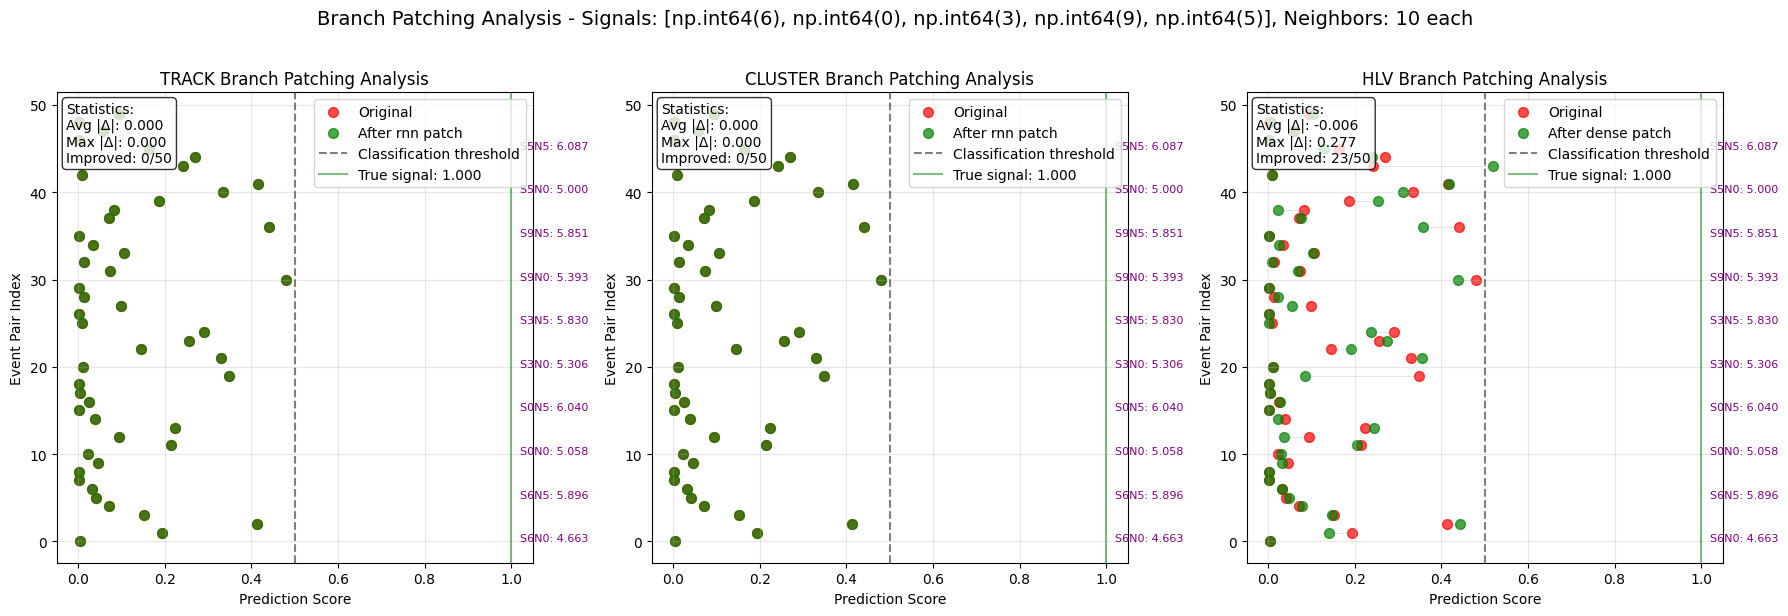

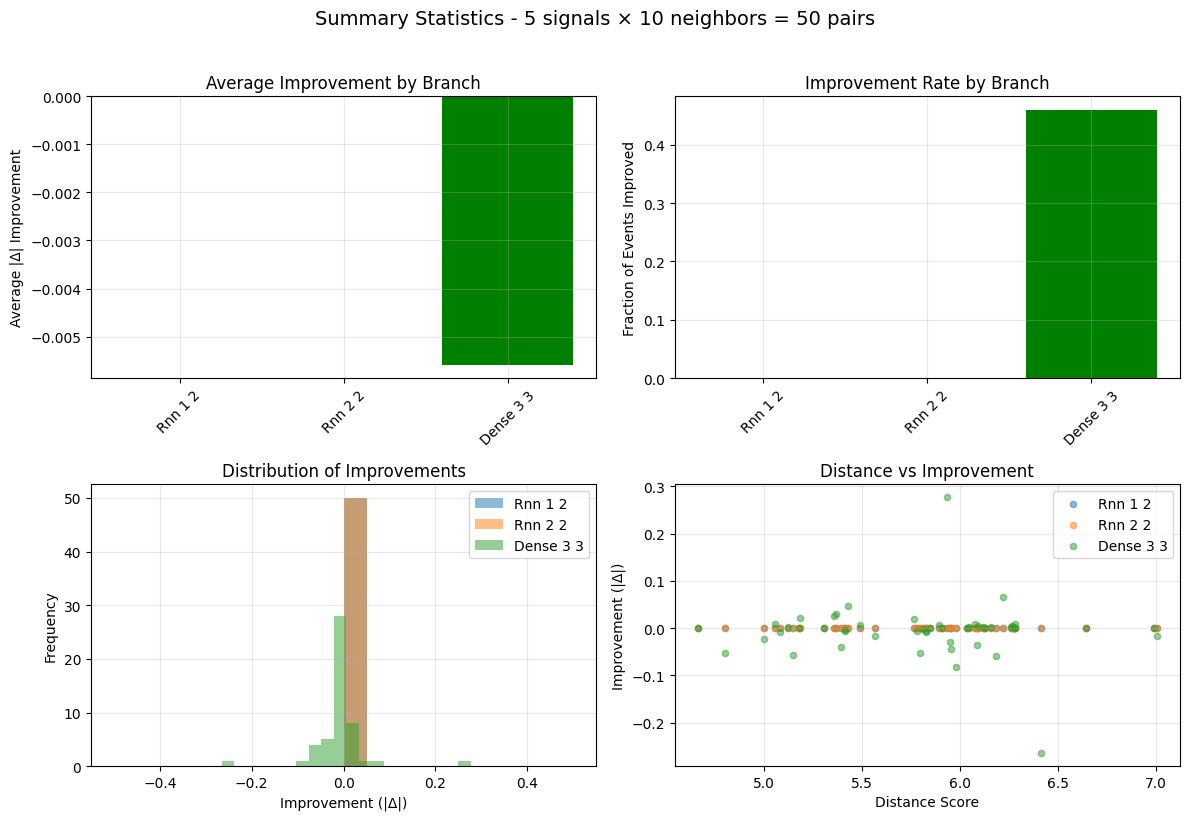

Analysis complete!


In [ ]:
def main():
    """Run analysis on events with larger differences"""
    npz_filename, model_filename = upload_files()

    # Load data to check which events have the biggest differences
    data = np.load(npz_filename)
    signal_preds = data['correct_signal_predictions']
    neighbor_preds = data['incorrect_neighbor_predictions']

    # Find signal events with biggest prediction differences from their neighbors
    pred_diffs = np.abs(signal_preds[:, np.newaxis] - neighbor_preds).mean(axis=1)
    top_different_signals = np.argsort(-pred_diffs)[:5]  # Top 5 most different

    print(f"Signal events with biggest differences: {top_different_signals}")
    print(f"Their prediction differences: {pred_diffs[top_different_signals]}")

    # Run analysis on these events
    results, data = run_branch_patching_analysis(
        npz_filename, model_filename,
        list(top_different_signals), 10, None
    )

    # Create visualizations
    branch_stats = create_branch_patching_plots(
        results, data, list(top_different_signals), 10
    )

    print("Analysis complete!")

if __name__ == "__main__":
    main()